<div style="background:linear-gradient(135deg,#431407 0%,#c2410c 55%,#fb923c 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#ffedd5;font-weight:700;text-transform:uppercase">Chapter 92 · Simple Linear Regression</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Simple Linear Regression</div>
  <div style="font-size:15px;color:#fff7ed;max-width:740px;line-height:1.6">Fit a line the right way: the five-step workflow, confidence and prediction bands, residual diagnostics, and the log-transform fix, all with statsmodels and seaborn.</div>
  <div style="margin-top:16px;font-size:13px;color:#ffedd5">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

## Simple linear regression, the five-step way
This notebook is deliberately **library-first**: we lean on `statsmodels` and `seaborn` and write almost no formulas by hand. We fit a line, read it, visualize the **confidence and prediction bands**, check the **LINE** conditions on the residuals, and finish by *breaking* a model and fixing it with a log transform, the workflow's feedback loop in action.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns   # seaborn = high-level statistical plots (heatmaps, regplots, pairplots)
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.nonparametric.smoothers_lowess import lowess
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
ORG="#ea580c"; DEEP="#c2410c"; LIGHT="#fdba74"; INK="#1a2138"; GRID="#e6e9f2"; GREEN="#059669"; RED="#ef4444"; AMBER="#d97706"; BLUE="#2563eb"; PUR="#9333ea"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
sns.set_style("whitegrid")
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"

<div style="background:#ecfdf5;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">DEMO 1 &#183; STEPS 1&#8211;2</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Explore, then fit the line</div>
<div style="color:#4a5578;margin-top:6px">Load real home sales, look before modeling, then fit price on size with one call to statsmodels.</div>
</div>

In [2]:
# Real dataset: load locally if present, else from the book's GitHub
try:
    homes = pd.read_excel('../../data/ch92_homes.xlsx', sheet_name='Sales')
except FileNotFoundError:
    homes = pd.read_excel(BASE + 'ch92_homes.xlsx', sheet_name='Sales')
print(homes.shape)
homes[['size_sqft','bedrooms','age_years','price']].describe().round(0)

(180, 6)


,size_sqft,bedrooms,age_years,price
count,180.0,180.0,180.0,180.0
mean,2220.0,3.0,28.0,455944.0
std,797.0,1.0,16.0,146084.0
min,823.0,1.0,0.0,178100.0
25%,1600.0,2.0,15.0,335025.0
50%,2282.0,3.0,28.0,466250.0
75%,2931.0,4.0,42.0,576475.0
max,3443.0,5.0,54.0,728400.0


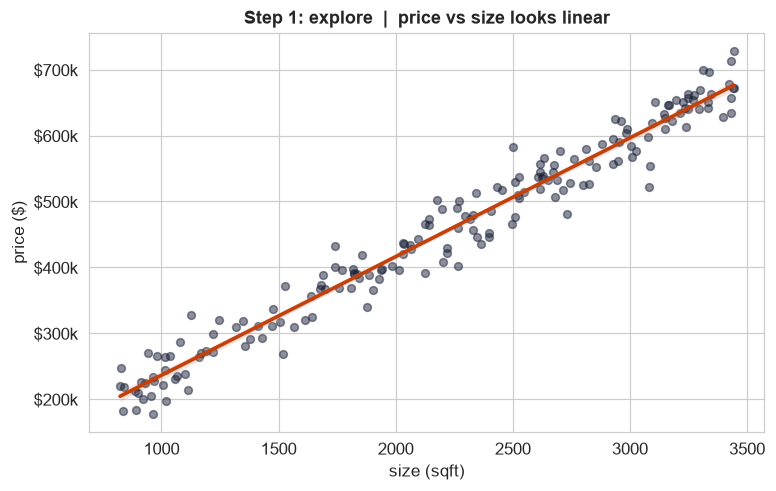

In [3]:
# EXPLORE FIRST: is the relationship plausibly a straight line? (seaborn does scatter + fit + CI band)
fig, ax = plt.subplots(figsize=(7.2,4.6))
sns.regplot(data=homes, x='size_sqft', y='price', ax=ax,
            scatter_kws=dict(s=26, color=INK, alpha=0.5), line_kws=dict(color=DEEP, lw=2.4))
ax.set(title='Step 1: explore  |  price vs size looks linear', xlabel='size (sqft)', ylabel='price ($)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'${v/1000:.0f}k'))
plt.tight_layout(); plt.show()

In [4]:
# STEP 2: define and fit with least squares (one line)
model = ols('price ~ size_sqft', data=homes).fit()
print(model.summary().tables[1])

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   5.604e+04   6077.839      9.221      0.000     4.4e+04     6.8e+04
size_sqft    180.1314      2.578     69.882      0.000     175.045     185.218


In [5]:
# The four numbers to know by heart
slope = model.params['size_sqft']; lo, hi = model.conf_int().loc['size_sqft']
print(f'slope        : ${slope:,.1f} per sqft   (95% CI ${lo:,.0f} to ${hi:,.0f})')
print(f'intercept    : ${model.params["Intercept"]:,.0f}')
print(f'R-squared    : {model.rsquared:.3f}   ({model.rsquared*100:.0f}% of price variation explained)')
print(f'resid std err: ${np.sqrt(model.scale):,.0f}   (typical prediction miss)')

slope        : $180.1 per sqft   (95% CI $175 to $185)
intercept    : $56,041
R-squared    : 0.965   (96% of price variation explained)
resid std err: $27,472   (typical prediction miss)


<div style="background:#fff7ed;border-left:5px solid #ea580c;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#c2410c;letter-spacing:1px">DEMO 2 &#183; STEP 5</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Confidence vs prediction bands</div>
<div style="color:#4a5578;margin-top:6px">The single most useful regression picture: the fitted line, a narrow band for the mean, and a wide band for a single new home.</div>
</div>

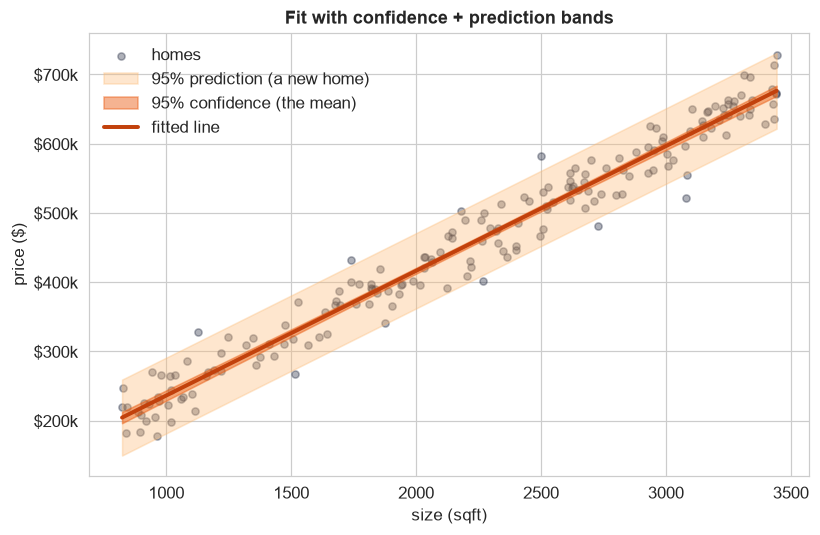

In [6]:
# statsmodels gives BOTH intervals across a grid of x, no manual algebra
grid = pd.DataFrame({'size_sqft': np.linspace(homes.size_sqft.min(), homes.size_sqft.max(), 120)})
pred = model.get_prediction(grid).summary_frame(alpha=0.05)
fig, ax = plt.subplots(figsize=(7.6,5))
ax.scatter(homes.size_sqft, homes.price, s=22, color=INK, alpha=0.35, label='homes')
ax.fill_between(grid.size_sqft, pred['obs_ci_lower'], pred['obs_ci_upper'], color=LIGHT, alpha=0.35, label='95% prediction (a new home)')
ax.fill_between(grid.size_sqft, pred['mean_ci_lower'], pred['mean_ci_upper'], color=ORG, alpha=0.45, label='95% confidence (the mean)')
ax.plot(grid.size_sqft, pred['mean'], color=DEEP, lw=2.6, label='fitted line')
ax.set(title='Fit with confidence + prediction bands', xlabel='size (sqft)', ylabel='price ($)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'${v/1000:.0f}k')); ax.legend(loc='upper left')
plt.tight_layout(); plt.show()

In [7]:
# Predict a single 2,000 sqft home: two very different 'give or take' answers
p = model.get_prediction(pd.DataFrame({'size_sqft':[2000]})).summary_frame(alpha=0.05).iloc[0]
print(f"point prediction     : ${p['mean']:,.0f}")
print(f"95% confidence (mean) : ${p['mean_ci_lower']:,.0f} to ${p['mean_ci_upper']:,.0f}   (narrow)")
print(f"95% prediction (one)  : ${p['obs_ci_lower']:,.0f} to ${p['obs_ci_upper']:,.0f}   (wide)")

point prediction     : $416,304
95% confidence (mean) : $412,111 to $420,496   (narrow)
95% prediction (one)  : $361,929 to $470,678   (wide)


<div style="background:#fff7ed;border-left:5px solid #ea580c;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#c2410c;letter-spacing:1px">DEMO 3 &#183; STEPS 3&#8211;4</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Evaluate adequacy and check the conditions</div>
<div style="color:#4a5578;margin-top:6px">Interrogate the residuals. A shapeless band and a straight Q-Q plot mean the LINE conditions hold.</div>
</div>

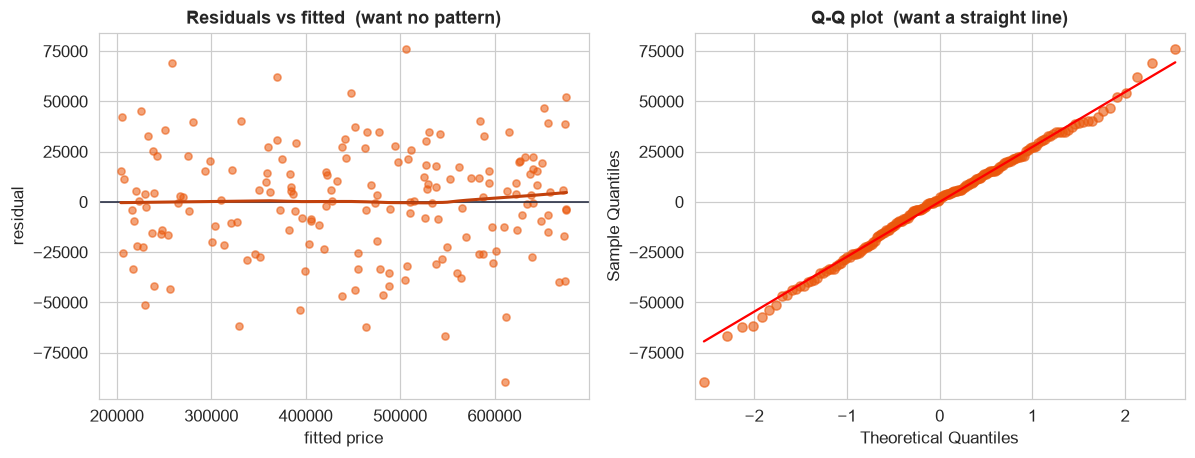

In [8]:
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson, jarque_bera
resid, fitted = model.resid, model.fittedvalues
fig, ax = plt.subplots(1, 2, figsize=(11,4.3))
ax[0].scatter(fitted, resid, s=22, color=ORG, alpha=0.55); ax[0].axhline(0, color=INK, lw=1)
sm_low = lowess(resid, fitted, frac=0.6)
ax[0].plot(sm_low[:,0], sm_low[:,1], color=DEEP, lw=2)
ax[0].set(title='Residuals vs fitted  (want no pattern)', xlabel='fitted price', ylabel='residual')
sm.qqplot(resid, line='s', ax=ax[1], markerfacecolor=ORG, markeredgecolor=ORG, alpha=0.6)
ax[1].set_title('Q-Q plot  (want a straight line)')
plt.tight_layout(); plt.show()

In [9]:
# Turn the plots into decisions with formal tests
bp = het_breuschpagan(resid, model.model.exog)[1]
jb = jarque_bera(resid)[1]
print(f'Equal variance  Breusch-Pagan p = {bp:.2f}   -> {"OK" if bp>0.05 else "violated"}')
print(f'Normality       Jarque-Bera   p = {jb:.2f}   -> {"OK" if jb>0.05 else "violated"}')
print(f'Independence    Durbin-Watson   = {durbin_watson(resid):.2f}   -> OK if near 2')

Equal variance  Breusch-Pagan p = 0.81   -> OK
Normality       Jarque-Bera   p = 0.47   -> OK
Independence    Durbin-Watson   = 2.22   -> OK if near 2


<div style="background:#fff7ed;border-left:5px solid #ea580c;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#c2410c;letter-spacing:1px">DEMO 4 &#183; THE FEEDBACK LOOP</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">When a condition fails: break it, then fix it</div>
<div style="color:#4a5578;margin-top:6px">A response that grows multiplicatively produces a funnel. Watch the diagnostics fail, then watch a log transform repair them.</div>
</div>

In [10]:
# Simulate a BROKEN case: y grows multiplicatively, so variance grows with the level
rng = np.random.default_rng(1)
x = rng.uniform(1, 10, 250)
y = np.exp(1.2 + 0.35*x + rng.normal(0, 0.35, 250))   # multiplicative noise -> heteroscedastic
bad = pd.DataFrame({'x':x, 'y':y})
m_bad = ols('y ~ x', bad).fit()
bp_bad = het_breuschpagan(m_bad.resid, m_bad.model.exog)[1]
print(f'RAW model:  R2 = {m_bad.rsquared:.2f}   Breusch-Pagan p = {bp_bad:.4f}  -> equal variance {"violated" if bp_bad<0.05 else "OK"}')

RAW model:  R2 = 0.68   Breusch-Pagan p = 0.0001  -> equal variance violated


LOG model:  R2 = 0.89   Breusch-Pagan p = 0.384  -> equal variance OK


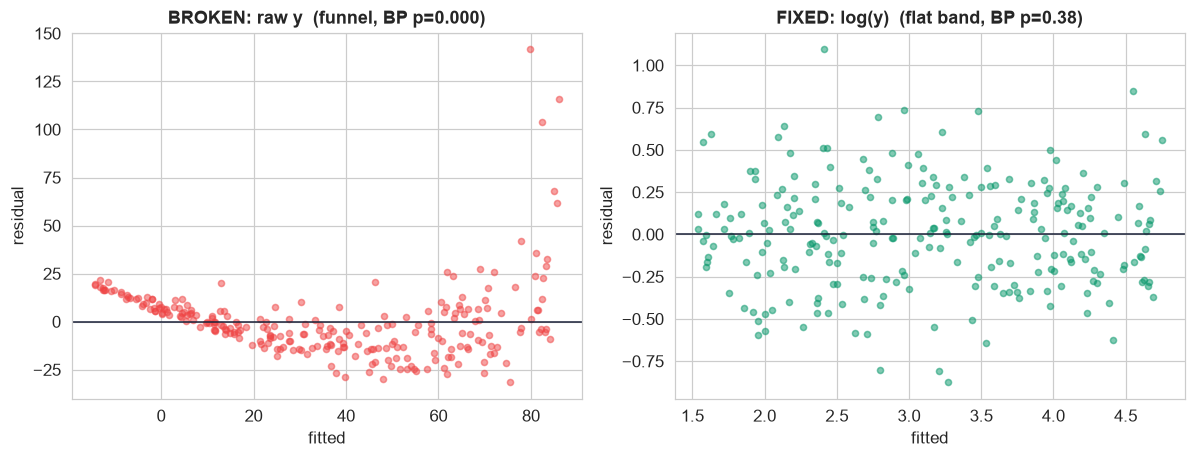

In [11]:
# Fix: model log(y). Compare residual-vs-fitted before and after.
bad['logy'] = np.log(bad['y'])
m_fix = ols('logy ~ x', bad).fit()
bp_fix = het_breuschpagan(m_fix.resid, m_fix.model.exog)[1]
print(f'LOG model:  R2 = {m_fix.rsquared:.2f}   Breusch-Pagan p = {bp_fix:.3f}  -> equal variance {"OK" if bp_fix>0.05 else "violated"}')
fig, ax = plt.subplots(1, 2, figsize=(11,4.3), sharey=False)
ax[0].scatter(m_bad.fittedvalues, m_bad.resid, s=16, color=RED, alpha=0.5); ax[0].axhline(0,color=INK,lw=1)
ax[0].set(title=f'BROKEN: raw y  (funnel, BP p={bp_bad:.3f})', xlabel='fitted', ylabel='residual')
ax[1].scatter(m_fix.fittedvalues, m_fix.resid, s=16, color=GREEN, alpha=0.5); ax[1].axhline(0,color=INK,lw=1)
ax[1].set(title=f'FIXED: log(y)  (flat band, BP p={bp_fix:.2f})', xlabel='fitted', ylabel='residual')
plt.tight_layout(); plt.show()

**The takeaway:** the log transform straightened the relationship *and* stabilized the variance in one move, turning a violated model into a valid one. That is step 4 doing its job, catch the problem on the residuals, loop back, and re-fit.

---
<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:10px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>